In [1]:
import numpy as np
import pandas as pd
import cobra
from cobra.io import read_sbml_model
from scipy.optimize import dual_annealing
from cobra import Model as CobraModel
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', 
                        message='DataFrame is highly fragmented', 
                        category=pd.errors.PerformanceWarning)
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from itertools import combinations
import ast
from upsetplot import UpSet
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

In [19]:
#this is using simoff without the initial single optimisations (see figure 3b, step 1)
#this version of simoff was used to create data for figure 4 and equations 1 and 2
#because I wanted to run these single optimisations separately so they could be visualised
def simoff_annealing_portion(
    model,
    objective_reactions,
    qualitative_constraints,
    bounds=None,
    max_iter=1000,
    initialtemp=5230,
    maxfun=1000
):
    import numpy as np
    import pandas as pd
    import cobra
    from cobra.io import read_sbml_model
    from scipy.optimize import dual_annealing
    from cobra import Model as CobraModel
    import matplotlib.pyplot as plt
    import math
    import warnings
    warnings.filterwarnings('ignore', 
                           message='DataFrame is highly fragmented', 
                           category=pd.errors.PerformanceWarning)

    # --- Input checks ---
    if not isinstance(model, CobraModel):
        raise TypeError("Model must be a cobra.Model instance")
    if not isinstance(objective_reactions, list):
        raise TypeError("objective_reactions must be a list of reaction IDs")
    if not isinstance(qualitative_constraints, dict):
        raise TypeError("qualitative_constraints must be a dictionary")
        
    invalid_values = {k: v for k, v in qualitative_constraints.items() if v not in {-1, 0, 1}}
    if invalid_values:
        raise ValueError(f"Invalid reaction direction values: {invalid_values}")

    # --- Allow uptake if needed ---
    for k, v in qualitative_constraints.items():
        if v == -1 and not model.reactions.get_by_id(k).reversibility:
            model.reactions.get_by_id(k).lower_bound = -1000
            print(f"Updated bounds for {k} to allow uptake")

    print(f"\nOptimisation: fitting objective(s) {objective_reactions} "
          f"to match {len(qualitative_constraints)} qualitative constraints")

    if bounds is None:
        bounds = [(-1, 1)] * len(objective_reactions)

    selected_rxns = list(qualitative_constraints.keys())
    results_log = []
    agreement_matrix = {}

    # variable to store early stop result
    early_stop_data = None

    # --- Objective evaluation ---
    def evaluate_solution(c_raw):
        nonlocal early_stop_data

        # normalize so abs sum = 1
        if np.sum(np.abs(c_raw)) == 0:
            c = np.zeros_like(c_raw)
        else:
            c = c_raw / np.sum(np.abs(c_raw))

        # set objective coefficients
        for i, rxn_id in enumerate(objective_reactions):
            model.reactions.get_by_id(rxn_id).objective_coefficient = c[i]

        solution = model.optimize()

        flux_dict = {}
        agreement_dict = {}
        if solution is None:
            accuracy = 0.0
            mismatch_count = len(selected_rxns)
            for rxn_id in selected_rxns:
                flux_dict[rxn_id] = None
                agreement_dict[rxn_id] = 0
        else:
            fluxes = solution.fluxes[selected_rxns]
            expected = np.array([qualitative_constraints[r] for r in selected_rxns])
            rounded_fluxes = np.where(np.abs(fluxes) < 1e-6, 0, np.sign(fluxes).astype(int))
            mismatch_count = np.count_nonzero(rounded_fluxes != expected)
            accuracy = 1 - (mismatch_count / len(expected))
            flux_dict = dict(zip(selected_rxns, fluxes))
            agreement_dict = {rxn_id: int(round_f == exp)
                              for rxn_id, round_f, exp in zip(selected_rxns, rounded_fluxes, expected)}

        results_log.append({'coefficients': c.tolist(), 'accuracy': accuracy, 'fluxes': flux_dict})
        agreement_matrix[len(results_log) - 1] = agreement_dict

        return 1 - accuracy

    # --- Auto temperature ---
    if initialtemp == 'auto':
        random_costs = []
        for _ in range(20):
            rand_coeffs = np.random.uniform(-1, 1, len(objective_reactions))
            cost = evaluate_solution(rand_coeffs)
            random_costs.append(cost)
        avg_delta_e = np.mean([abs(a - b) for a, b in zip(random_costs[:-1], random_costs[1:])])
        initialtemp = max(1.0, avg_delta_e / -math.log(1.0))
        print(f"Estimated initial temperature: {initialtemp:.2f}")

    # --- Run annealing with graceful early stop ---
    result = dual_annealing(
            evaluate_solution,
            bounds,
            maxiter=max_iter,
            initial_temp=initialtemp,
            maxfun=maxfun
        )

    # --- If not perfect, finalize results ---
    if np.sum(np.abs(result.x)) == 0:
        scaled_coeffs = np.zeros_like(result.x)
    else:
        scaled_coeffs = result.x / np.sum(np.abs(result.x))

    for i, rxn_id in enumerate(objective_reactions):
        model.reactions.get_by_id(rxn_id).objective_coefficient = scaled_coeffs[i]

    solution = model.optimize()
    fluxes = solution.fluxes[selected_rxns]
    expected = np.array([qualitative_constraints[r] for r in selected_rxns])
    rounded_fluxes = np.where(np.abs(fluxes) < 1e-6, 0, np.sign(fluxes).astype(int))
    accuracy = 1 - (np.count_nonzero(rounded_fluxes != expected) / len(expected))

    # --- Logging ---
    log_df = pd.DataFrame(results_log)
    agreement_df = pd.DataFrame.from_dict(agreement_matrix, orient='index').T

    # --- Convergence plot ---
    #sampled_df = log_df.iloc[::10]
    #fig, ax = plt.subplots(figsize=(8, 4))
    #ax.plot(sampled_df.index, sampled_df['accuracy'], marker='o', linestyle='-', color='black')
    #ax.set_xlabel('Iteration')
    #ax.set_ylabel('Accuracy')
    #ax.set_title('Accuracy Over Time (Every 10th Evaluation)')
    #ax.grid(True)

    print("\nOptimization complete.")
    print("Optimal Coefficients:", dict(zip(objective_reactions, scaled_coeffs)))
    print(f"Final Accuracy: {accuracy:.2%}")

    return dict(zip(objective_reactions, scaled_coeffs)), accuracy, log_df, agreement_df

def plot_agreement_heatmaps(function_result, num_columns=100): #function_result: the result of optimize_objective_from_qualitative_criteria_agreement function
    """
    Plots heatmaps of agreement (binary 0/1) for the first and last `num_columns` iterations.

    Parameters:
        agreement_df (pd.DataFrame): DataFrame with reaction IDs as rows and iteration steps as columns.
        num_columns (int): Number of columns (iterations) to plot per subplot (default: 100).
    """
    
    agreement_df = function_result[4]
    id_to_name = {rxn.id: rxn.name for rxn in model.reactions}
    agreement_df.index = agreement_df.index.map(lambda rid: id_to_name.get(rid, rid))  # fallback to ID if name missing
    num_cols = agreement_df.shape[1]
    cols_to_plot = min(num_columns, num_cols)

    first_chunk = agreement_df.iloc[:, :cols_to_plot]
    last_chunk = agreement_df.iloc[:, -cols_to_plot:]

    # Define custom colormap
    cmap = mcolors.ListedColormap(["#d63384", "#20c997"])  # red for 0, green for 1
    bounds = [-0.5, 0.5, 1.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create subplots
    fig_height = max(6, len(agreement_df) * 0.4)
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(cols_to_plot / 4, fig_height))

    # Plot first chunk
    sns.heatmap(
        first_chunk,
        ax=axes[0],
        cmap=cmap,
        norm=norm,
        cbar=False,
        linewidths=0.2,
        linecolor='white',
        square=False,
        xticklabels=max(1, cols_to_plot // 10),
        yticklabels=True
    )
    axes[0].set_title(f"First {cols_to_plot} Iterations", fontsize=10)
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Reaction ID")

    # Plot last chunk
    sns.heatmap(
        last_chunk,
        ax=axes[1],
        cmap=cmap,
        norm=norm,
        cbar=False,
        linewidths=0.2,
        linecolor='white',
        square=False,
        xticklabels=max(1, cols_to_plot // 10),
        yticklabels=True
    )
    axes[1].set_title(f"Last {cols_to_plot} Iterations", fontsize=10)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Reaction ID")

    axes[1].set_xticklabels(
        axes[1].get_xticklabels(),
        rotation=45,
        ha='right',
        fontsize=10
    )

    plt.tight_layout()
    plt.show()

def extract_and_plot_coefficients(function_result, step=10): #function_result: the result of optimize_objective_from_qualitative_criteria_agreement function
    # Get reaction IDs from the first iteration
    reaction_ids = list(function_result[0].keys())
    
    # Initialize dictionary to store coefficients for each reaction
    coeff_dict = {rid: [] for rid in reaction_ids}

    # Collect coefficients from each iteration
    for row in function_result[2].iloc[:, 0]:
        for i, rid in enumerate(reaction_ids):
            coeff_dict[rid].append(row[i])

    # Plotting
    num_reactions = len(reaction_ids)
    num_rows = (num_reactions + 1) // 2
    fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(14, 4 * num_rows))
    axes = axes.flatten()

    x_axis = list(range(0, len(function_result[2]), step))

    colors = ['black', 'blue', 'red', 'green', 'purple', 'brown', 'orange', 'cyan']

    for i, rid in enumerate(reaction_ids):
        ax = axes[i]
        ax.plot(x_axis, coeff_dict[rid][::step], marker='o', linestyle='-', color=colors[i % len(colors)])
        reaction_name = model.reactions.get_by_id(rid).name
        ax.set_title(f'{rid}: {reaction_name}')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Coefficient in objective function')
        ax.grid(True)
        ax.axhline(0, color='orange', linestyle='--', linewidth=2)
        ax.set_ylim(-1, 1)

    # Hide any unused subplots
    for j in range(num_reactions, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [3]:
#import model
model = read_sbml_model('yeast-GEM.xml')

#specify qualitative input criteria, based on experimental cell behaviour
criteria_faster = {'r_2111':1,'r_1714':-1,'r_1761':1,'r_1808':1,'r_1654':-1}
criteria_slower = {'r_2111':1,'r_1714':-1,'r_1761':0,'r_1808':0,'r_1654':-1}

#define a minimial medium within model (or set to be your experimental culture conditions)
from cobra.medium import minimal_medium
max_growth = model.slim_optimize()
minimal = minimal_medium(model, max_growth)
minimal_dict = minimal.to_dict()
model.medium = minimal_dict
print(model.medium)

#check that the input objectives are in the media so that these metabolites can actually be transported
#if they're not in the media, then open the reactions so that they can exchange freely
#D-glucose
if 'r_1714' in minimal_dict.keys():
    print('r_1714 already defined')
elif 'r_1714' not in minimal_dict.keys():
    minimal_dict['r_1714'] = 1
    print(minimal_dict['r_1714'])

#Ethanol
if 'r_1761' in minimal_dict.keys():
    print('r_1761 already defined')
elif 'r_1761' not in minimal_dict.keys():
    minimal_dict['r_1761'] = 1
    print(minimal_dict['r_1761'])

#Glycerol
if 'r_1808' in minimal_dict.keys():
    print('r_1808 already defined')
elif 'r_1808' not in minimal_dict.keys():
    minimal_dict['r_1808'] = 1
    print(minimal_dict['r_1808'])

#Ammonium
if 'r_1654' in minimal_dict.keys():
    print('r_1654 already defined')
elif 'r_1654' not in minimal_dict.keys():
    minimal_dict['r_1654'] = 1
    print(minimal_dict['r_1654'])

model.medium = minimal_dict
print(model.medium)

{'r_1654': 0.5987757792265652, 'r_1714': 1.0, 'r_1832': 0.042355921812448995, 'r_1861': 2.629679636262737e-06, 'r_1992': 2.25005295947331, 'r_2005': 0.544948527084135, 'r_2020': 0.00030400435553062504, 'r_2049': 0.00033247859553473083, 'r_2060': 0.0072031713974737635, 'r_4593': 0.00010803461132465607, 'r_4594': 5.518977345077752e-05, 'r_4595': 0.0002286313844895006, 'r_4596': 6.264332215932059e-05, 'r_4597': 0.00010406018935736309, 'r_4600': 1.817326290786762e-05}
r_1714 already defined
1
1
r_1654 already defined
{'r_1654': 0.5987757792265652, 'r_1714': 1.0, 'r_1761': 1, 'r_1808': 1, 'r_1832': 0.042355921812448995, 'r_1861': 2.629679636262737e-06, 'r_1992': 2.25005295947331, 'r_2005': 0.544948527084135, 'r_2020': 0.00030400435553062504, 'r_2049': 0.00033247859553473083, 'r_2060': 0.0072031713974737635, 'r_4593': 0.00010803461132465607, 'r_4594': 5.518977345077752e-05, 'r_4595': 0.0002286313844895006, 'r_4596': 6.264332215932059e-05, 'r_4597': 0.00010406018935736309, 'r_4600': 1.8173262

### Equation 1: slower growing yeast condition

In [ ]:
#this is the code that ran to get results for equation 1 and figure 4
%%time
objectives = ['r_2111', 'r_1761', 'r_1808', 'r_1714', 'r_1654']

#print all possible combinations of input reactions
all_combos = []
for r in range(1, len(objectives) + 1):
    all_combos.extend(combinations(objectives, r))
    all_combos = [list(t) for t in all_combos]
print(f"There are {len(all_combos)} possible combinations of objectives.\n")

results = {}
for combo in all_combos:
    if len(combo) > 1:
        results[tuple(combo)] = annealing_2(model, combo, criteria_slower, bounds=None, max_iter=300,initialtemp=30, maxfun=5000)
        if results[tuple(combo)][1] == 1.0:
            print(print("\n🎯 Perfect 100% accuracy achieved, so dropped out of loop"))
            break

In [4]:
#since the above cell was ran in another notebook, results have been imported here for visualisation
%store -r working_slow_combinations_300

In [14]:
print('slower growing yeast simoff output:')
for k,v in working_slow_combinations_300.items():
    if working_slow_combinations_300[k][1] == 1:
        print(working_slow_combinations_300[k][0],working_slow_combinations_300[k][1],working_slow_combinations_300[k][2],
             working_slow_combinations_300[k][4])
        slower_300_successful = working_slow_combinations_300[k]
        break

slower growing yeast simoff output:
{'r_2111': np.float64(0.7708830797138203), 'r_1761': np.float64(0.004608909329164195), 'r_1808': np.float64(0.014767472962852756), 'r_1654': np.float64(-0.2097405379941627)} 1.0                                            coefficients  accuracy  \
0     [-0.24072813223839815, -0.3846375058493703, 0....       0.2   
1     [0.2661255296159834, 0.2639460790462826, 0.241...       0.2   
2     [-0.2327462193957683, 0.28940930314499563, -0....       0.4   
3     [-0.38682734077572567, -0.2093625639795024, -0...       0.4   
4     [-0.3797479333229524, 0.0455559769842363, 0.28...       0.2   
...                                                 ...       ...   
2214  [0.7773212798003785, -0.0032225114031807635, 0...       0.8   
2215  [0.7773210027394529, -0.0032225102545797727, 0...       0.8   
2216  [0.7542817224569364, -0.0028378987116755494, 0...       0.6   
2217  [0.778922525581164, -0.0032353670662545893, 0....       0.8   
2218  [0.7708830797138203, 

### Equation 2: faster growing yeast condition

In [ ]:
#faster growing condition

#run simoff for each combination of input reactions
results = {}
for combo in all_combos:
    if len(combo) > 1:
        #these were the hyperparameters used for faster growing condition in figures 4 and 5
        results[tuple(combo)] = annealing_2(model, combo, criteria_faster, bounds=None, max_iter=50,initialtemp=30, maxfun=2000)
        if results[tuple(combo)][1] == 1.0:
            print(print("\n🎯 Perfect 100% accuracy achieved, so dropped out of loop"))
            break

There are 31 possible combinations of objectives.


Optimisation: fitting objective(s) ['r_2111', 'r_1761'] to match 5 qualitative constraints

Optimization complete.
Optimal Coefficients: {'r_2111': np.float64(0.9618825509683394), 'r_1761': np.float64(0.03811744903166058)}
Final Accuracy: 80.00%

Optimisation: fitting objective(s) ['r_2111', 'r_1808'] to match 5 qualitative constraints

Optimization complete.
Optimal Coefficients: {'r_2111': np.float64(0.6416395325366546), 'r_1808': np.float64(-0.3583604674633454)}
Final Accuracy: 80.00%

Optimisation: fitting objective(s) ['r_2111', 'r_1714'] to match 5 qualitative constraints

Optimization complete.
Optimal Coefficients: {'r_2111': np.float64(0.6451626384436195), 'r_1714': np.float64(-0.3548373615563805)}
Final Accuracy: 80.00%

Optimisation: fitting objective(s) ['r_2111', 'r_1654'] to match 5 qualitative constraints

Optimization complete.
Optimal Coefficients: {'r_2111': np.float64(0.9018447353327477), 'r_1654': np.float64(-0.098

In [12]:
#since the above cell was ran in another notebook, results have been imported here for visualisation
%store -r working_results_faster_combo_50

In [15]:
print('faster growing yeast simoff output:')
for k,v in working_results_faster_combo_50.items():
    if working_results_faster_combo_50[k][1] == 1:
        print(working_results_faster_combo_50[k][0],working_results_faster_combo_50[k][1],working_results_faster_combo_50[k][2],
             working_results_faster_combo_50[k][4])
        faster_50_successful = working_results_faster_combo_50[k]
        break

faster growing yeast simoff output:
{'r_2111': np.float64(0.9495431331375206), 'r_1808': np.float64(0.050456866862479396)} 1.0                                    coefficients  accuracy  \
0    [0.05633052438121155, -0.9436694756187884]       0.4   
1    [0.16573619283218213, -0.8342638071678179]       0.4   
2     [0.5360983976276175, 0.46390160237238254]       0.4   
3     [-0.4490894362660041, 0.5509105637339959]       0.4   
4    [-0.36235960948991114, 0.6376403905100888]       0.4   
..                                          ...       ...   
142   [0.6931410806965776, 0.30685891930342235]       0.4   
143    [0.40433976586872594, 0.595660234131274]       0.4   
144  [0.9580483805912365, 0.041951619408763505]       0.8   
145  [-0.9373802799212785, 0.06261972007872153]       0.4   
146  [0.9495431331375206, 0.050456866862479396]       1.0   

                                                fluxes  
0    {'r_2111': 0.0, 'r_1714': -1.0, 'r_1761': 3.16...  
1    {'r_2111': 0.0, 'r_17

### Figure 4a

Biomass: 1 optimisation -->
growth actual: 1, predicted: 1 --> agree
D-glucose exchange actual: -1, predicted: -1 --> agree
ethanol exchange actual: 0, predicted: 1 --> mismatch
glycerol exchange actual: 0, predicted: -1 --> mismatch
ammonium exchange actual: -1, predicted: -1 --> agree

D-Glucose: -1 optimisation -->
growth actual: 1, predicted: 1 --> agree
D-glucose exchange actual: -1, predicted: -1 --> agree
ethanol exchange actual: 0, predicted: 1 --> mismatch
glycerol exchange actual: 0, predicted: -1 --> mismatch
ammonium exchange actual: -1, predicted: -1 --> agree

Ammonium: -1 optimisation -->
growth actual: 1, predicted: 1 --> agree
D-glucose exchange actual: -1, predicted: -1 --> agree
ethanol exchange actual: 0, predicted: 1 --> mismatch
glycerol exchange actual: 0, predicted: -1 --> mismatch
ammonium exchange actual: -1, predicted: -1 --> agree



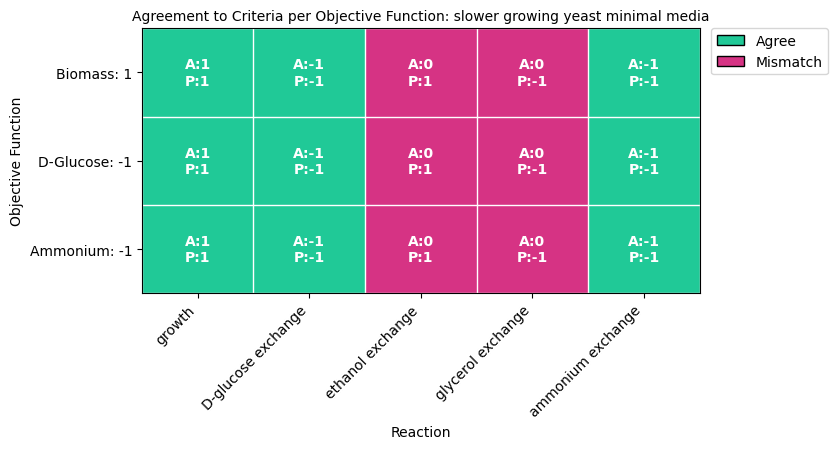

In [16]:
#Detailed mismatch grid for slower-growing
all_results = {}

objectives = {
    'Biomass: 1': ('r_2111', 1),
    'D-Glucose: -1': ('r_1714', -1),
    'Ammonium: -1': ('r_1654', -1)
}

#change from criteria_faster and skip the 0 optimisations so only three rows

for obj_name, (rxn_id, coeff) in objectives.items():
    obj_dict = {}
    print(f'{obj_name} optimisation -->')
    with model:
        model.objective = {model.reactions.get_by_id(rxn_id): coeff}
        solution = model.optimize()
        for r_id in criteria_slower:
            predicted = np.where(np.abs(solution.fluxes[r_id]) < 1e-6, 0, np.sign(solution.fluxes[r_id]).astype(int))
            rxn_name = model.reactions.get_by_id(r_id).name
            obj_dict[rxn_name] = {
                'actual': criteria_slower[r_id],
                'predicted': int(predicted),
                'agreement': 'agree' if predicted == criteria_slower[r_id] else 'mismatch'
            }
            print(f"{rxn_name} actual: {criteria_slower[r_id]}, predicted: {int(predicted)} --> {obj_dict[rxn_name]['agreement']}")
    all_results[obj_name] = obj_dict
    print('')

# --- Build agreement matrix ---
reaction_names = list(next(iter(all_results.values())).keys())
objective_names = list(all_results.keys())
agree_matrix = np.zeros((len(objective_names), len(reaction_names)), dtype=int)
text_matrix = np.empty(agree_matrix.shape, dtype=object)

for i, obj in enumerate(objective_names):
    for j, rxn in enumerate(reaction_names):
        agree_matrix[i, j] = 1 if all_results[obj][rxn]['agreement'] == 'agree' else 0
        actual = all_results[obj][rxn]['actual']
        predicted = all_results[obj][rxn]['predicted']
        text_matrix[i, j] = f"A:{actual}\nP:{predicted}"

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(1.5*len(reaction_names)+1, 1.2*len(objective_names)+1))
cmap = ListedColormap(["#d63384", "#20c997"])  # Red=mismatch, Teal=agree
im = ax.imshow(agree_matrix, cmap=cmap, vmin=0, vmax=1, aspect='auto')

ax.set_xticks(np.arange(len(reaction_names)))
ax.set_yticks(np.arange(len(objective_names)))
ax.set_xticklabels(reaction_names, rotation=45, ha='right')
ax.set_yticklabels(objective_names)

# Gridlines
ax.set_xticks(np.arange(-.5, len(reaction_names), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(objective_names), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)

# Overlay text
for i in range(len(objective_names)):
    for j in range(len(reaction_names)):
        ax.text(j, i, text_matrix[i, j], ha='center', va='center', color='white', fontsize=10, fontweight='bold')

# Legend
legend_patches = [Patch(facecolor='#20c997', edgecolor='k', label='Agree'),
                  Patch(facecolor='#d63384', edgecolor='k', label='Mismatch')]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1.0), loc='upper left', borderaxespad=0.)

ax.set_title("Agreement to Criteria per Objective Function: slower growing yeast minimal media", fontsize=10)
ax.set_ylabel("Objective Function")
ax.set_xlabel("Reaction")
plt.tight_layout()
#plt.savefig('agreement_simple_objectives_slower_min_media_19112025_2.png',bbox_inches='tight',dpi=300)
plt.show()

### Figure 4b

C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the in

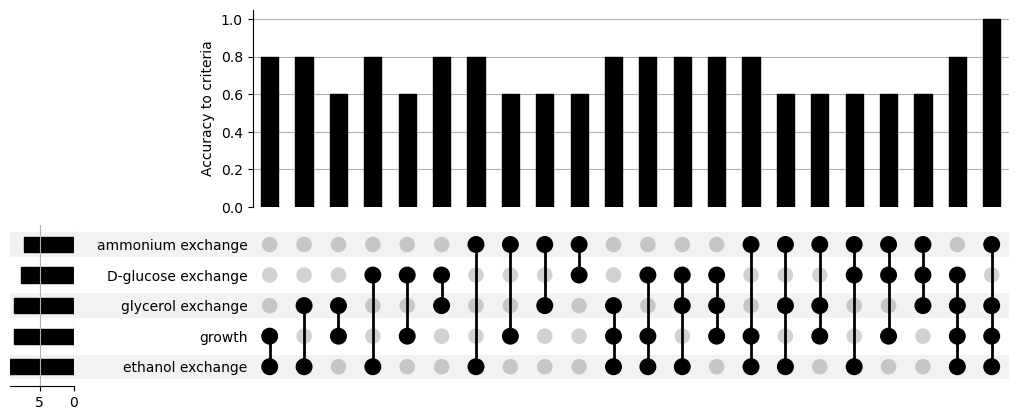

In [17]:
result = working_slow_combinations_300

result_dict = {}
for key, v in result.items():
    accuracy = v[1]             
    result_dict[key] = accuracy
    if accuracy == 1:
        break

objectives = ['r_2111', 'r_1714', 'r_1761', 'r_1808', 'r_1654']
reaction_names = {r_id: model.reactions.get_by_id(r_id).name for r_id in objectives}

index = []
values = []

for combo, acc in result_dict.items():
    # combo is a tuple of reactions
    # Create tuple of booleans: True if reaction is in combo
    presence_tuple = tuple(rxn in combo for rxn in objectives)

    index.append(presence_tuple)
    values.append(acc)

multi_index = pd.MultiIndex.from_tuples(
    index,
    names=[reaction_names[r] for r in objectives]
)

s = pd.Series(values, index=multi_index, name='accuracy')

upset = UpSet(s, subset_size='sum')
ax_dict = upset.plot()

ax_dict['intersections'].set_ylabel("Accuracy to criteria")

#plt.savefig('upset_slower_300_growing_18112025.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 4c

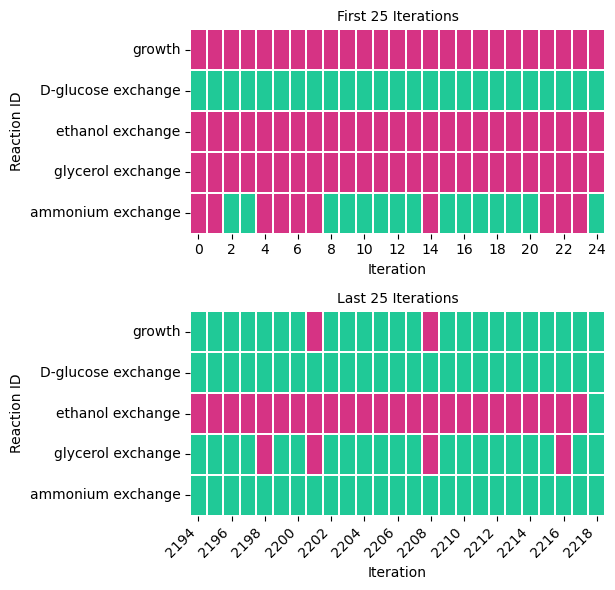

In [20]:
plot_agreement_heatmaps(slower_300_successful,num_columns=25)

### Figure 4d

Biomass: 1 optimisation -->
growth actual: 1, predicted: 1 --> agree
D-glucose exchange actual: -1, predicted: -1 --> agree
ethanol exchange actual: 1, predicted: 1 --> agree
glycerol exchange actual: 1, predicted: -1 --> mismatch
ammonium exchange actual: -1, predicted: -1 --> agree

D-Glucose: -1 optimisation -->
growth actual: 1, predicted: 1 --> agree
D-glucose exchange actual: -1, predicted: -1 --> agree
ethanol exchange actual: 1, predicted: 1 --> agree
glycerol exchange actual: 1, predicted: -1 --> mismatch
ammonium exchange actual: -1, predicted: -1 --> agree

Ethanol: 1 optimisation -->
growth actual: 1, predicted: 0 --> mismatch
D-glucose exchange actual: -1, predicted: -1 --> agree
ethanol exchange actual: 1, predicted: 1 --> agree
glycerol exchange actual: 1, predicted: -1 --> mismatch
ammonium exchange actual: -1, predicted: 0 --> mismatch

Glycerol: 1 optimisation -->
growth actual: 1, predicted: 0 --> mismatch
D-glucose exchange actual: -1, predicted: -1 --> agree
ethano

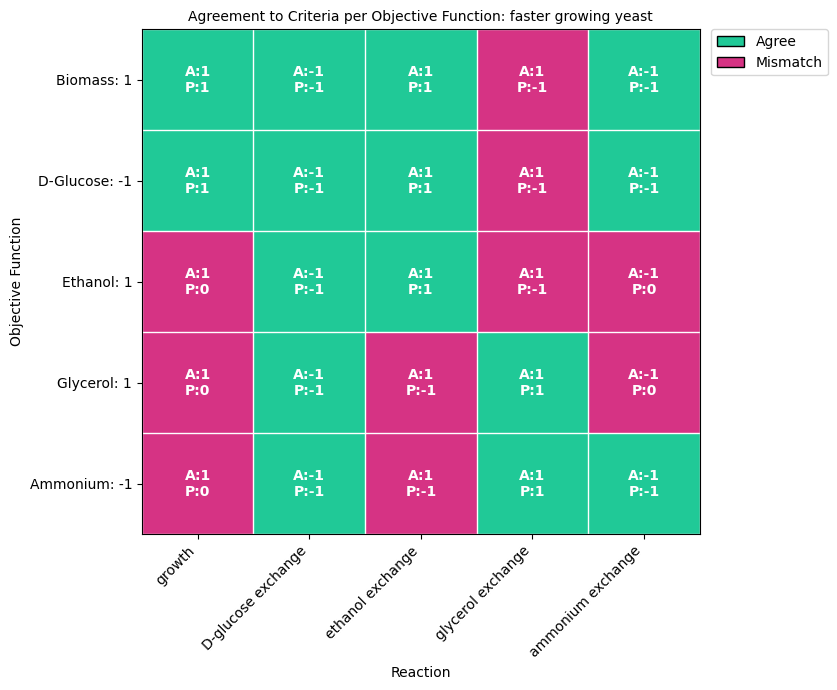

In [21]:
all_results = {}

objectives = {
    'Biomass: 1': ('r_2111', 1),
    'D-Glucose: -1': ('r_1714', -1),
    'Ethanol: 1': ('r_1761', 1),
    'Glycerol: 1': ('r_1808', 1),
    'Ammonium: -1': ('r_1654', -1)
}

for obj_name, (rxn_id, coeff) in objectives.items():
    obj_dict = {}
    print(f'{obj_name} optimisation -->')
    with model:
        model.objective = {model.reactions.get_by_id(rxn_id): coeff}
        solution = model.optimize()
        for r_id in criteria_faster:
            predicted = np.where(np.abs(solution.fluxes[r_id]) < 1e-6, 0, np.sign(solution.fluxes[r_id]).astype(int))
            rxn_name = model.reactions.get_by_id(r_id).name
            obj_dict[rxn_name] = {
                'actual': criteria_faster[r_id],
                'predicted': int(predicted),
                'agreement': 'agree' if predicted == criteria_faster[r_id] else 'mismatch'
            }
            print(f"{rxn_name} actual: {criteria_faster[r_id]}, predicted: {int(predicted)} --> {obj_dict[rxn_name]['agreement']}")
    all_results[obj_name] = obj_dict
    print('')

# --- Build agreement matrix ---
reaction_names = list(next(iter(all_results.values())).keys())
objective_names = list(all_results.keys())
agree_matrix = np.zeros((len(objective_names), len(reaction_names)), dtype=int)
text_matrix = np.empty(agree_matrix.shape, dtype=object)

for i, obj in enumerate(objective_names):
    for j, rxn in enumerate(reaction_names):
        agree_matrix[i, j] = 1 if all_results[obj][rxn]['agreement'] == 'agree' else 0
        actual = all_results[obj][rxn]['actual']
        predicted = all_results[obj][rxn]['predicted']
        text_matrix[i, j] = f"A:{actual}\nP:{predicted}"

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(1.5*len(reaction_names)+1, 1.2*len(objective_names)+1))
cmap = ListedColormap(["#d63384", "#20c997"])  # Red=mismatch, Teal=agree
im = ax.imshow(agree_matrix, cmap=cmap, vmin=0, vmax=1, aspect='auto')

ax.set_xticks(np.arange(len(reaction_names)))
ax.set_yticks(np.arange(len(objective_names)))
ax.set_xticklabels(reaction_names, rotation=45, ha='right')
ax.set_yticklabels(objective_names)

# Gridlines
ax.set_xticks(np.arange(-.5, len(reaction_names), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(objective_names), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)

# Overlay text
for i in range(len(objective_names)):
    for j in range(len(reaction_names)):
        ax.text(j, i, text_matrix[i, j], ha='center', va='center', color='white', fontsize=10, fontweight='bold')

# Legend
legend_patches = [Patch(facecolor="#20c997", edgecolor='k', label='Agree'),
                  Patch(facecolor="#d63384", edgecolor='k', label='Mismatch')]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1.0), loc='upper left', borderaxespad=0.)

ax.set_title("Agreement to Criteria per Objective Function: faster growing yeast",fontsize=10)
ax.set_ylabel("Objective Function")
ax.set_xlabel("Reaction")
plt.tight_layout()
#plt.savefig('agreement_simple_objectives_faster_media_19112025_2.png',bbox_inches='tight',dpi=300)
plt.show()

### Figure 4e

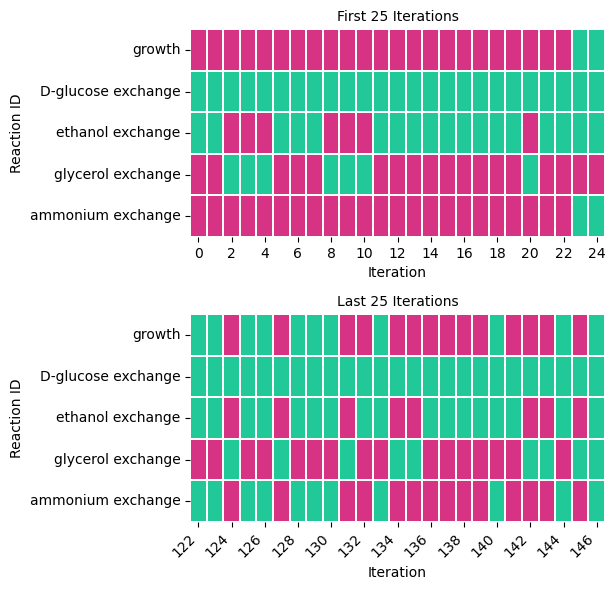

In [22]:
plot_agreement_heatmaps(faster_50_successful,num_columns=25)